<style>
@keyframes glowPulse {
  0% { box-shadow: 0 0 0 rgba(245, 158, 11, 0.0); transform: translateY(0px); }
  50% { box-shadow: 0 12px 30px rgba(245, 158, 11, 0.25); transform: translateY(-2px); }
  100% { box-shadow: 0 0 0 rgba(245, 158, 11, 0.0); transform: translateY(0px); }
}
</style>

<div style="background: linear-gradient(135deg, #0b1220 0%, #7c2d12 42%, #14532d 100%); padding: 30px 24px; border-radius: 18px; color: #f8fafc; text-align: center; margin-bottom: 16px; animation: glowPulse 4.5s ease-in-out infinite;">
  <h1 style="margin: 0; font-size: 33px; letter-spacing: 0.4px;">Video Tracking Inference Notebook</h1>
  <p style="margin: 10px 0 0 0; font-size: 15px; opacity: 0.92;">Task 4 • Kaggle T4 Optimized • Standalone MP4 Tracking</p>
  <div style="margin-top: 14px; display: inline-flex; gap: 10px; flex-wrap: wrap; justify-content: center;">
    <span style="background: rgba(255,255,255,0.14); padding: 6px 14px; border-radius: 999px; font-size: 12px;">Boxes + IDs</span>
    <span style="background: rgba(255,255,255,0.14); padding: 6px 14px; border-radius: 999px; font-size: 12px;">Trails + Arrows</span>
    <span style="background: rgba(255,255,255,0.14); padding: 6px 14px; border-radius: 999px; font-size: 12px;">Counting Line</span>
    <span style="background: rgba(255,255,255,0.14); padding: 6px 14px; border-radius: 999px; font-size: 12px;">Density Heatmap</span>
  </div>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-bottom: 10px;">
  <div style="background: #f0f9ff; border: 1px solid #bae6fd; border-radius: 12px; padding: 14px;">
    <h4 style="color: #075985; margin: 0 0 8px 0;">Run Mode A: From Main Notebook State</h4>
    <p style="color: #0f172a; margin: 0; font-size: 13.5px; line-height: 1.6;">Keep <code>STATE_PATH</code> set. The notebook will auto-load class names and best YOLO weights from <code>project_state.json</code>.</p>
  </div>
  <div style="background: #fff7ed; border: 1px solid #fed7aa; border-radius: 12px; padding: 14px;">
    <h4 style="color: #9a3412; margin: 0 0 8px 0;">Run Mode B: Direct Weights + MP4</h4>
    <p style="color: #0f172a; margin: 0; font-size: 13.5px; line-height: 1.6;">Set <code>YOLO_WEIGHTS_PATH</code> and <code>VIDEO_PATH</code> in CONFIG. This mode works even without the main notebook state file.</p>
  </div>
</div>

<div style="background: #fef3c7; border-left: 5px solid #d97706; padding: 14px 16px; border-radius: 8px;">
  <p style="margin: 0; color: #78350f; font-size: 13.5px; line-height: 1.6;">
    Before running: attach your video dataset in Kaggle, verify <code>VIDEO_PATH</code>, and keep GPU enabled (T4/P100).
  </p>
</div>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Video   : /kaggle/input/datasets/turjo410/cctv-1-video-daylight/Ch095 20250927171010 012(1).mp4
Weights : yolo26n.pt
Classes : ['car', 'bus', 'truck', 'motorcycle', 'bicycle', 'rickshaw', 'van', 'person']
Video: 1920x1080 @ 25.0 FPS, total=106296 frames, counting line y=594
Processing window: start=9000 end=10200 (frames=1200)
  Frame 0/1200 | Tracks:4 | Crossed:0 | 0.4 FPS
  Frame 100/1200 | Tracks:6 | Crossed:0 | 16.1 FPS
  Frame 200/1200 | Tracks:4 | Crossed:4 | 19.5 FPS
  Frame 300

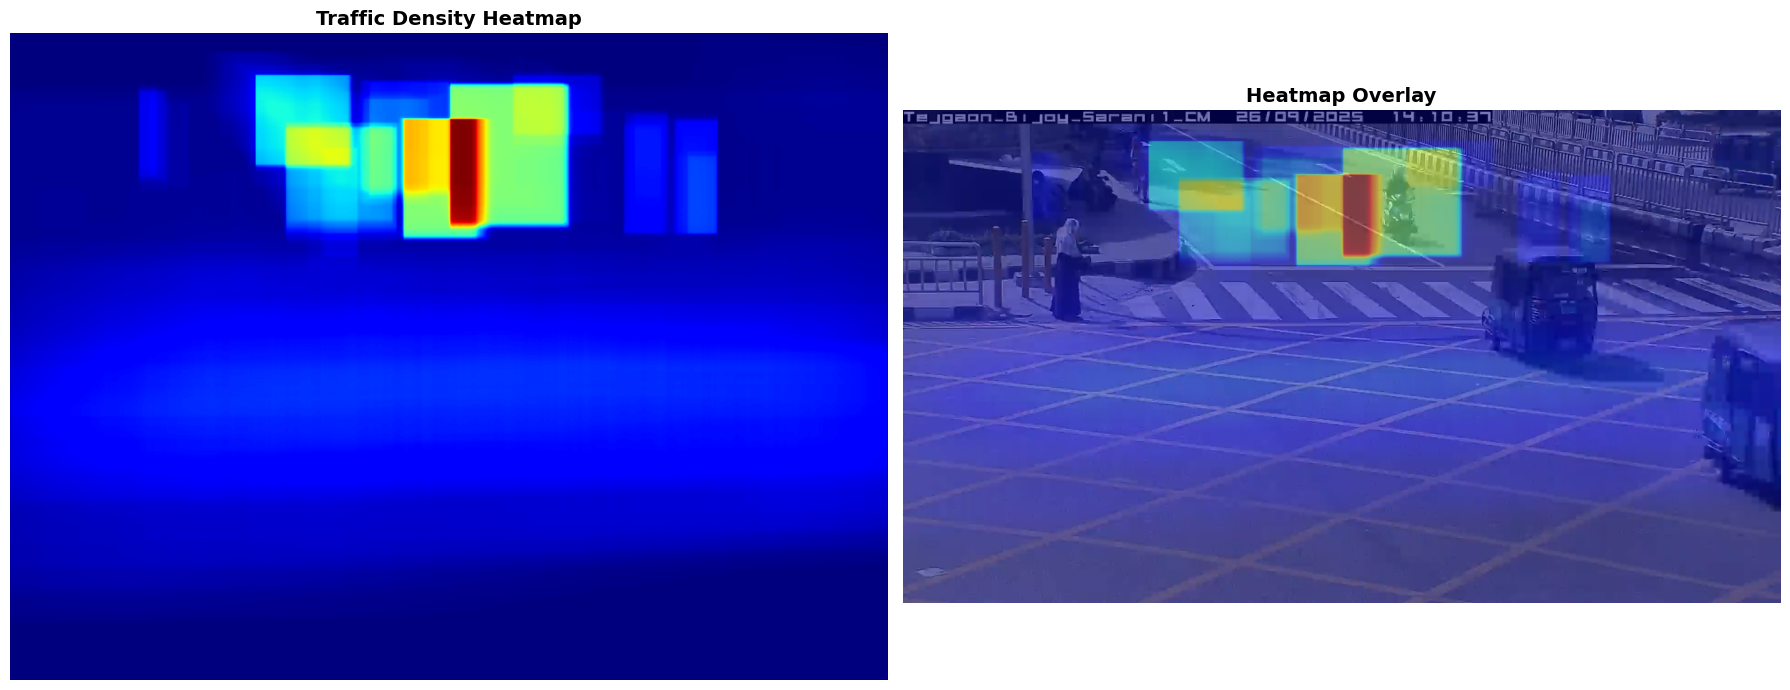

Heatmap: /kaggle/working/bd_traffic_assignment/video_outputs/traffic_density_heatmap.png

--- Crossing Summary ---


,Class,Count
0,motorcycle,7
1,car,6
2,truck,6
3,person,4
4,rickshaw,1
5,cls_8,1


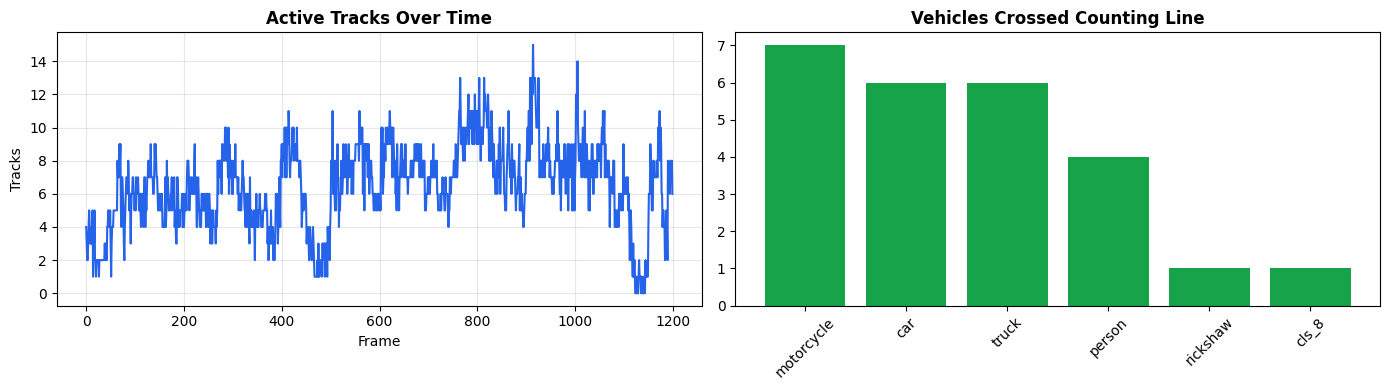


All outputs: /kaggle/working/bd_traffic_assignment/video_outputs


In [1]:
# ============================================================
# Task 4 — Video Tracking & Traffic Analysis
# All required overlays: boxes, IDs, trails, arrows,
# counting line, live count panel, density heatmap
# ============================================================

!pip -q install -U ultralytics filterpy

import gc
import cv2
import json
import time
import torch
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, deque, Counter
from copy import deepcopy
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter
from ultralytics import YOLO
from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURATION — UPDATE THESE PATHS IN KAGGLE
# ============================================================
CONFIG = {
    # REQUIRED: set this to your uploaded MP4 path in Kaggle
    "VIDEO_PATH": "/kaggle/input/datasets/turjo410/cctv-1-video-daylight/Ch095 20250927171010 012(1).mp4",
    # Optional: state file from main notebook; keep None to run with direct weights
    "STATE_PATH": "/kaggle/working/bd_traffic_assignment/project_state.json",
    # Optional explicit model path. If provided, this overrides state paths.
    "YOLO_WEIGHTS_PATH": "",
    "OUTPUT_DIR": "/kaggle/working/bd_traffic_assignment/video_outputs",
    # Runtime-quality balance for T4
    "MAX_FRAMES": 1200,
    "START_SECOND": 360,
    "PROCESS_SECONDS": 720,
    "CONF_THRES": 0.25,
    "IOU_THRES": 0.50,
    "COUNTING_LINE_Y_RATIO": 0.55,
    "TRAIL_LENGTH": 30,
    "YOLO_IMGSZ": 640,
    # Fallback class names if state is unavailable
    "FALLBACK_CLASS_NAMES": ["car", "bus", "truck", "motorcycle", "bicycle", "rickshaw", "van", "person"],
}

VIDEO_PATH = Path(CONFIG["VIDEO_PATH"])
STATE_PATH = Path(CONFIG["STATE_PATH"]) if CONFIG.get("STATE_PATH") else None
OUTPUT_DIR = Path(CONFIG["OUTPUT_DIR"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_FRAMES = CONFIG["MAX_FRAMES"]
START_SECOND = float(CONFIG.get("START_SECOND", 0))
PROCESS_SECONDS = CONFIG.get("PROCESS_SECONDS", 120)
CONF_THRES = float(CONFIG["CONF_THRES"])
IOU_THRES = float(CONFIG["IOU_THRES"])
COUNTING_LINE_Y_RATIO = float(CONFIG["COUNTING_LINE_Y_RATIO"])
TRAIL_LENGTH = int(CONFIG["TRAIL_LENGTH"])

if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"Video not found: {VIDEO_PATH}. Update CONFIG['VIDEO_PATH'] to your Kaggle MP4 path."
    )

state = {}
if STATE_PATH is not None and STATE_PATH.exists():
    state = json.loads(STATE_PATH.read_text())

CLASS_NAMES = state.get("class_names", CONFIG["FALLBACK_CLASS_NAMES"])
YOLO_IMGSZ = int(state.get("yolo_imgsz", CONFIG["YOLO_IMGSZ"]))

weight_candidates = []
if CONFIG.get("YOLO_WEIGHTS_PATH"):
    weight_candidates.append(CONFIG["YOLO_WEIGHTS_PATH"])
for k in ["saved_yolo_best_path", "yolo_best_path"]:
    if state.get(k):
        weight_candidates.append(state[k])
weight_candidates.extend(["yolo26n.pt", "yolo11n.pt"])

yolo_model = None
loaded_weight = None
last_error = None
for wt in weight_candidates:
    try:
        yolo_model = YOLO(str(wt))
        loaded_weight = str(wt)
        break
    except Exception as e:
        last_error = e

if yolo_model is None:
    raise RuntimeError(f"Failed to load YOLO weights. Last error: {last_error}")

print(f"Video   : {VIDEO_PATH}")
print(f"Weights : {loaded_weight}")
print(f"Classes : {CLASS_NAMES}")

# ============================================================
# Geometry helpers
# ============================================================
def xyxy_to_xcycwh(box):
    x1, y1, x2, y2 = box[:4]
    w, h = max(0, x2-x1), max(0, y2-y1)
    return np.array([x1+w/2, y1+h/2, w, h], dtype=np.float32)

def xcycwh_to_xyxy(sv):
    cx, cy, w, h = sv[:4]
    return np.array([cx-w/2, cy-h/2, cx+w/2, cy+h/2], dtype=np.float32)

def compute_iou_matrix(a, b):
    if len(a)==0 or len(b)==0: return np.zeros((len(a),len(b)),dtype=np.float32)
    a,b = np.asarray(a,dtype=np.float32), np.asarray(b,dtype=np.float32)
    x1=np.maximum(a[:,None,0],b[None,:,0]); y1=np.maximum(a[:,None,1],b[None,:,1])
    x2=np.minimum(a[:,None,2],b[None,:,2]); y2=np.minimum(a[:,None,3],b[None,:,3])
    inter=np.maximum(0,x2-x1)*np.maximum(0,y2-y1)
    aa=np.maximum(0,a[:,2]-a[:,0])*np.maximum(0,a[:,3]-a[:,1])
    ab=np.maximum(0,b[:,2]-b[:,0])*np.maximum(0,b[:,3]-b[:,1])
    u=aa[:,None]+ab[None,:]-inter
    return np.where(u>0,inter/u,0)

def hungarian_match(tb, db, tc=None, dc=None, iou_thr=0.30):
    if len(tb)==0 or len(db)==0: return [], list(range(len(tb))), list(range(len(db)))
    iou=compute_iou_matrix(np.asarray(tb),np.asarray(db))
    if tc is not None and dc is not None:
        iou[np.asarray(tc)[:,None]!=np.asarray(dc)[None,:]]=0
    cost=1-iou; ri,ci=linear_sum_assignment(cost)
    m,mt,md=[],set(),set()
    for r,c in zip(ri,ci):
        if iou[r,c]>=iou_thr: m.append((r,c)); mt.add(r); md.add(c)
    return m,[i for i in range(len(tb)) if i not in mt],[i for i in range(len(db)) if i not in md]

# ============================================================
# SORT Tracker
# ============================================================
class KalmanBoxTrack:
    count = 0
    def __init__(self, det, tl=30):
        self.kf=KalmanFilter(dim_x=8,dim_z=4)
        self.kf.F=np.eye(8,dtype=np.float32)
        for i in range(4): self.kf.F[i,i+4]=1
        self.kf.H=np.zeros((4,8),dtype=np.float32); self.kf.H[:4,:4]=np.eye(4)
        self.kf.P*=10; self.kf.P[4:,4:]*=1000; self.kf.R*=1; self.kf.Q*=0.01
        self.kf.x[:4]=xyxy_to_xcycwh(det[:4]).reshape((4,1))
        KalmanBoxTrack.count+=1; self.track_id=KalmanBoxTrack.count
        self.class_id=int(det[5]); self.score=float(det[4])
        self.tsu=0; self.hits=1; self.hs=1; self.age=0
        c=[(det[0]+det[2])/2,(det[1]+det[3])/2]
        self.trail=deque([c],maxlen=tl); self.prev_center=c; self.crossed=False
    def predict(self):
        self.kf.predict(); self.age+=1; self.tsu+=1
        if self.tsu>0: self.hs=0
        return xcycwh_to_xyxy(self.kf.x[:4].reshape(-1))
    def update(self, det):
        self.tsu=0; self.hits+=1; self.hs+=1
        self.class_id=int(det[5]); self.score=float(det[4])
        self.kf.update(xyxy_to_xcycwh(det[:4]).reshape((4,1)))
        b=xcycwh_to_xyxy(self.kf.x[:4].reshape(-1))
        self.prev_center=list(self.trail[-1]) if self.trail else [(b[0]+b[2])/2,(b[1]+b[3])/2]
        self.trail.append([(b[0]+b[2])/2,(b[1]+b[3])/2])
    def get_state(self): return xcycwh_to_xyxy(self.kf.x[:4].reshape(-1))

class VideoSortTracker:
    def __init__(self, iou_thr=0.30, max_age=5, min_hits=2, tl=30):
        KalmanBoxTrack.count=0; self.it=iou_thr; self.ma=max_age; self.mh=min_hits; self.tl=tl; self.fc=0; self.trackers=[]
    def update(self, dets, shape=None):
        self.fc+=1; pb,pc,vr=[],[],[]
        for t in self.trackers:
            p=t.predict()
            if np.isfinite(p).all():
                if shape: h,w=shape[:2]; p=np.clip(p,[0,0,0,0],[w-1,h-1,w-1,h-1])
                pb.append(p); pc.append(t.class_id); vr.append(t)
            else: t.tsu=self.ma+1
        self.trackers=vr
        pa=np.asarray(pb) if pb else np.zeros((0,4))
        db=dets[:,:4] if len(dets) else np.zeros((0,4))
        dc=dets[:,5].astype(int) if len(dets) else np.zeros((0,),dtype=int)
        m,_,ud=hungarian_match(pa,db,tc=np.asarray(pc) if pc else None,dc=dc if len(dc) else None,iou_thr=self.it)
        for ti,di in m: self.trackers[ti].update(dets[di])
        for di in ud: self.trackers.append(KalmanBoxTrack(dets[di],tl=self.tl))
        self.trackers=[t for t in self.trackers if t.tsu<=self.ma]
        return [t for t in self.trackers if t.tsu==0 and (t.hits>=self.mh or self.fc<=self.mh)]

# ============================================================
# Color palette
# ============================================================
_COLORS=[(0,255,127),(255,165,0),(30,144,255),(255,69,0),(50,205,50),(220,20,60),(0,206,209),(148,103,189),(255,215,0)]
def cc(i): return _COLORS[i%len(_COLORS)]

# ============================================================
# Process Video
# ============================================================
cap=cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened()
fps=cap.get(cv2.CAP_PROP_FPS) or 30
fw=int(cap.get(3)); fh=int(cap.get(4)); tf=int(cap.get(7))
cly=int(fh*COUNTING_LINE_Y_RATIO)

start_frame = int(max(0, START_SECOND * fps))
if start_frame >= tf:
    raise ValueError(f"START_SECOND ({START_SECOND}) is outside video length.")
if start_frame > 0:
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

if PROCESS_SECONDS is None:
    requested_frames = tf - start_frame
else:
    requested_frames = int(max(1, float(PROCESS_SECONDS) * fps))

if MAX_FRAMES:
    requested_frames = min(requested_frames, int(MAX_FRAMES))

plim = min(requested_frames, tf - start_frame)
end_frame = start_frame + plim

print(f"Video: {fw}x{fh} @ {fps:.1f} FPS, total={tf} frames, counting line y={cly}")
print(f"Processing window: start={start_frame} end={end_frame} (frames={plim})")

out_path=OUTPUT_DIR/"tracked_output.mp4"
writer=cv2.VideoWriter(str(out_path),cv2.VideoWriter_fourcc(*"mp4v"),fps,(fw,fh))
heatmap=np.zeros((fh,fw),dtype=np.float64)
tracker=VideoSortTracker(iou_thr=0.30,max_age=5,min_hits=2,tl=TRAIL_LENGTH)
crossed_ids=set(); crossing_count=defaultdict(int); frame_stats=[]
fi=0; t0=time.perf_counter()

while cap.isOpened() and fi<plim:
    ret,frame=cap.read()
    if not ret: break
    rgb=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

    # Detect
    r=yolo_model.predict(rgb,conf=CONF_THRES,imgsz=YOLO_IMGSZ,verbose=False)[0]
    if r.boxes is not None and len(r.boxes)>0:
        dets=np.concatenate([r.boxes.xyxy.cpu().numpy().astype(np.float32),
                             r.boxes.conf.cpu().numpy().astype(np.float32)[:,None],
                             r.boxes.cls.cpu().numpy().astype(np.float32)[:,None]],axis=1)
    else: dets=np.zeros((0,6),dtype=np.float32)

    # Track
    active=tracker.update(dets,shape=frame.shape)
    out=frame.copy()

    # Counting line
    cv2.line(out,(0,cly),(fw,cly),(0,255,255),2)
    cv2.putText(out,"COUNTING LINE",(10,cly-8),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,255),2)

    cur_counts=defaultdict(int)
    for t in active:
        b=t.get_state().astype(int); x1,y1,x2,y2=b.tolist()
        ci=t.class_id; tid=t.track_id; sc=t.score; col=cc(ci)
        cn=CLASS_NAMES[ci] if ci<len(CLASS_NAMES) else f"cls_{ci}"
        cur_counts[cn]+=1

        # Box + label
        cv2.rectangle(out,(x1,y1),(x2,y2),col,2)
        lbl=f"ID:{tid} {cn} {sc:.2f}"
        (tw,th),_=cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,0.45,1)
        cv2.rectangle(out,(x1,y1-th-6),(x1+tw,y1),col,-1)
        cv2.putText(out,lbl,(x1,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.45,(0,0,0),1,cv2.LINE_AA)

        # Trail
        trail=list(t.trail)
        for i in range(1,len(trail)):
            p1=(int(trail[i-1][0]),int(trail[i-1][1])); p2=(int(trail[i][0]),int(trail[i][1]))
            cv2.line(out,p1,p2,col,max(1,int(i/len(trail)*3)))

        # Arrow
        if len(trail)>=2:
            cv2.arrowedLine(out,(int(trail[-2][0]),int(trail[-2][1])),(int(trail[-1][0]),int(trail[-1][1])),(255,255,255),2,tipLength=0.3)

        # Counting
        cy_=(y1+y2)/2; pcy=t.prev_center[1]
        if not t.crossed and ((pcy<cly<=cy_) or (pcy>cly>=cy_)):
            t.crossed=True; crossed_ids.add(tid); crossing_count[cn]+=1

        # Heatmap
        cx_=int((x1+x2)/2); cy__=int((y1+y2)/2); bw_=max(10,x2-x1); bh_=max(10,y2-y1)
        hx1,hy1=max(0,cx_-bw_//2),max(0,cy__-bh_//2)
        hx2,hy2=min(fw,cx_+bw_//2),min(fh,cy__+bh_//2)
        heatmap[hy1:hy2,hx1:hx2]+=1

    # Live count panel
    ph=30+22*(len(cur_counts)+2); pw=220
    ov=out.copy()
    cv2.rectangle(ov,(fw-pw-10,10),(fw-10,10+ph),(0,0,0),-1)
    cv2.addWeighted(ov,0.7,out,0.3,0,out)
    cv2.putText(out,"LIVE COUNT",(fw-pw,32),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,255),2)
    yo=56
    for cn,cnt in sorted(cur_counts.items()):
        cv2.putText(out,f"{cn}: {cnt}",(fw-pw,yo),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1); yo+=22
    cv2.putText(out,f"Crossed: {sum(crossing_count.values())}",(fw-pw,yo),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,127),1); yo+=22
    cv2.putText(out,f"Frame: {fi}",(fw-pw,yo),cv2.FONT_HERSHEY_SIMPLEX,0.5,(180,180,180),1)

    writer.write(out)
    frame_stats.append({"frame":fi,"active_tracks":len(active),"total_crossed":sum(crossing_count.values())})
    if fi%100==0:
        el=time.perf_counter()-t0; pfps=(fi+1)/max(el,1e-9)
        print(f"  Frame {fi}/{plim} | Tracks:{len(active)} | Crossed:{sum(crossing_count.values())} | {pfps:.1f} FPS")
    fi+=1

cap.release(); writer.release()
tel=time.perf_counter()-t0
print(f"\nDone! {fi} frames in {tel:.1f}s ({fi/max(tel,1e-9):.1f} FPS)")
print(f"Output: {out_path}")
print("\nCrossing counts:")
for cn,cnt in sorted(crossing_count.items(),key=lambda x:-x[1]): print(f"  {cn}: {cnt}")

# ============================================================
# Heatmap
# ============================================================
hmap_path=OUTPUT_DIR/"traffic_density_heatmap.png"
fig,axes=plt.subplots(1,2,figsize=(18,7))
hn=heatmap/max(heatmap.max(),1)
axes[0].imshow(hn,cmap="jet",aspect="auto"); axes[0].set_title("Traffic Density Heatmap",fontsize=14,fontweight="bold"); axes[0].axis("off")
cap2=cv2.VideoCapture(str(VIDEO_PATH)); ret,ff=cap2.read(); cap2.release()
if ret:
    frgb=cv2.cvtColor(ff,cv2.COLOR_BGR2RGB)
    hc=cv2.applyColorMap((hn*255).astype(np.uint8),cv2.COLORMAP_JET)
    hr=cv2.cvtColor(hc,cv2.COLOR_BGR2RGB)
    ov2=cv2.addWeighted(frgb,0.5,hr,0.5,0)
    axes[1].imshow(ov2); axes[1].set_title("Heatmap Overlay",fontsize=14,fontweight="bold"); axes[1].axis("off")
plt.tight_layout(); plt.savefig(str(hmap_path),dpi=150,bbox_inches="tight"); plt.show()
print(f"Heatmap: {hmap_path}")

# ============================================================
# Statistics
# ============================================================
sdf=pd.DataFrame(frame_stats)
cdf=pd.DataFrame([{"Class":c,"Count":n} for c,n in sorted(crossing_count.items(),key=lambda x:-x[1])])
print("\n--- Crossing Summary ---"); display(cdf)
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(sdf["frame"],sdf["active_tracks"],lw=1.5,color="#2563eb")
axes[0].set_title("Active Tracks Over Time",fontweight="bold"); axes[0].set_xlabel("Frame"); axes[0].set_ylabel("Tracks"); axes[0].grid(alpha=0.3)
if len(cdf)>0:
    axes[1].bar(cdf["Class"],cdf["Count"],color="#16a34a")
    axes[1].set_title("Vehicles Crossed Counting Line",fontweight="bold"); axes[1].tick_params(axis="x",rotation=45)
plt.tight_layout(); plt.show()
sdf.to_csv(OUTPUT_DIR/"frame_stats.csv",index=False); cdf.to_csv(OUTPUT_DIR/"crossing_counts.csv",index=False)
print(f"\nAll outputs: {OUTPUT_DIR}")
gc.collect(); _=torch.cuda.empty_cache() if torch.cuda.is_available() else None



<div style="background: linear-gradient(135deg, #7c2d12 0%, #0f172a 50%, #14532d 100%); padding: 24px; border-radius: 14px; color: white; text-align: center; margin-top: 24px;">
  <h2 style="margin: 0;">✅ Video Inference Complete</h2>
  <p style="margin-top: 10px; font-size: 15px; opacity: 0.9;">Task 4 processed with all required overlays.</p>
</div>